<a href="https://colab.research.google.com/github/ryanmart25/bird-song-recognizer/blob/utils_setup/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bird Species Identifier
A model for identifying the species of bird from audio.

## Imports

In [7]:
ITERATION = 6
PAUL = True # paul, you are running in an environment with a different keras backend than us, and are using pytorch instead of tensorflow.
# use this flag to gate code that should be run when only you want it to run. 
# In general, my idea for these flags was they could be used to section off highly experimental / broken code, or code that only works in a specific
# environment that others might not have.
RYAN = True
BEN = True
WINDOW_SIZE = 6
OPTIMIZER_LEARNING_RATE = 0.001
GLOBAL_DISABLE = True; #When set to true, disables unnecessary code. Leave as is unless you neeD



In [5]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import sys
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, mean_squared_error
import matplotlib.pyplot as plt
from collections.abc import Sequence
from sklearn import preprocessing
%matplotlib inline
import csv
import glob
from IPython.display import Image
import seaborn as sns

import os

if (PAUL):
    os.environ["KERAS_BACKEND"] = "torch"   # must be set before 'import keras'
    import pydot
    import torch
    import keras
    from keras.utils import plot_model, load_img, img_to_array
    from keras import layers, models
    from keras.models import Sequential, Model
    from keras.layers import Dense, Dropout, Input, Flatten, Conv2D, MaxPooling2D, concatenate, Conv1D, MaxPooling1D, Dropout, Input, Conv2D, MaxPooling2D
    from keras.utils import plot_model
    from keras.optimizers import Adam
    from keras.callbacks import EarlyStopping, ModelCheckpoint
    print("Torch CUDA available:", torch.cuda.is_available())  # Should be true when running GPU processing, else ignore

else:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras.utils import plot_model
    from tensorflow.keras import layers, models
    from tensorflow.keras.models import Sequential, Model
    from tensorflow.keras.layers import Dense, Dropout, Input, Flatten, Conv2D, MaxPooling2D, concatenate, Conv1D, MaxPooling1D
    from tensorflow.keras.utils import plot_model
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
    from tensorflow.keras.utils import plot_model, load_img, img_to_array



ModuleNotFoundError: No module named 'torch'

## Global Control Flow Flags and Program Configuration

## Define Helper Methods

In [18]:
def plot_losses(history, base_path, iteration:int):
    # Plot training & validation loss over epochs
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.ylim(bottom=0.0, top=10.0)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs. Validation Loss")
    plt.legend()
    plt.savefig(
        os.path.join(base_path, f"training-validiation-loss--epoch---Model {iteration}")
    )
    plt.close()


def print_schema(dataframe: pd.DataFrame):
    print('~~~~~~dataframe schema~~~~~~')
    print(f"Dataframe shape: {dataframe.shape} | Dataframe length: {len(dataframe)}")
    print('Column labels: ')
    print(dataframe.columns)
    print('Dataframe head: ')
    print(f"{dataframe.head()}")
def print_column(dataframe: pd.DataFrame, columns: str | list[str]):
    if isinstance(columns, list):
        for i, label in enumerate(columns):
            print(f"column {i}")
            print(dataframe[label])
    else:
        print(dataframe[columns])
# Encode text values to dummy variables(i.e. [1,0,0],[0,1,0],[0,0,1] for red,green,blue)
def encode_text_dummy(df, name):
    dummies = pd.get_dummies(df[name])
    for x in dummies.columns:
        dummy_name = "{}-{}".format(name, x)
        df[dummy_name] = dummies[x]
    df.drop(name, axis=1, inplace=True)


# Encode text values to indexes(i.e. [1],[2],[3] for red,green,blue).
def encode_text_index(df, name):
    le = preprocessing.LabelEncoder()
    df[name] = le.fit_transform(df[name])
    return le.classes_


# Encode a numeric column as zscores
def encode_numeric_zscore(df, name, mean=None, sd=None):
    if mean is None:
        mean = df[name].mean()

    if sd is None:
        sd = df[name].std()

    df[name] = (df[name] - mean) / sd


# Convert all missing values in the specified column to the median
def missing_median(df, name):
    med = df[name].median()
    df[name] = df[name].fillna(med)


# Convert all missing values in the specified column to the default
def missing_default(df, name, default_value):
    df[name] = df[name].fillna(default_value)


# Convert a Pandas dataframe to the x,y inputs that TensorFlow needs
def to_xy(df, target):
    result = []
    for x in df.columns:
        if x != target:
            result.append(x)
    # find out the type of the target column.
    target_type = df[target].dtypes
    target_type = target_type[0] if isinstance(target_type, Sequence) else target_type
    # Encode to int for classification, float otherwise. TensorFlow likes 32 bits.
    #if target_type in (np.int64, np.int32):
        ## Classification
        #dummies = pd.get_dummies(df[target])
        #return df[result].values.astype(np.float32), dummies.values.astype(np.float32)
    #else#:
        ## Regression
    return df[result].values.astype(np.float32), df[target].values.astype(np.float32)

# Nicely formatted time string
def hms_string(sec_elapsed):
    h = int(sec_elapsed / (60 * 60))
    m = int((sec_elapsed % (60 * 60)) / 60)
    s = sec_elapsed % 60
    return "{}:{:>02}:{:>05.2f}".format(h, m, s)


# Regression chart.
def chart_regression(path, pred,y,sort=True):
    t = pd.DataFrame({'pred' : pred, 'y' : y.flatten()})
    if sort:
        t.sort_values(by=['y'],inplace=True)
    b = plt.plot(t['pred'].tolist(),label='prediction')
    a = plt.plot(t['y'].tolist(),label='expected')

    plt.ylabel('output')
    plt.legend()
    plt.savefig(path)
    plt.close()

# Remove all rows where the specified column is +/- sd standard deviations
def remove_outliers(df, name, sd):
    drop_rows = df.index[(np.abs(df[name] - df[name].mean()) >= (sd * df[name].std()))]
    df.drop(drop_rows, axis=0, inplace=True)


# Encode a column to a range between normalized_low and normalized_high.
def encode_numeric_range(df, name, normalized_low=-1, normalized_high=1,
                         data_low=None, data_high=None):
    if data_low is None:
        data_low = min(df[name])
        data_high = max(df[name])

    df[name] = ((df[name] - data_low) / (data_high - data_low)) \
               * (normalized_high - normalized_low) + normalized_low



## Import and Read Datasets

In [19]:
# import an API key for the dataset
if (not GLOBAL_DISABLE):

    from google.colab import files
    files.upload()

In [20]:
if (not GLOBAL_DISABLE):
    print("didn't run")

In [21]:
if (not GLOBAL_DISABLE):
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json



## Download Dataset

In [22]:
if (not GLOBAL_DISABLE):
    # The following code will only execute
    # successfully when compression is complete

    import kagglehub

    # Download latest version
    path = kagglehub.dataset_download("ryanmartinez2025/birdcall-spectrograms")

    print("Path to dataset files:", path)

## Configure Environment

In [23]:
if (not GLOBAL_DISABLE):

  import os
  import sys
  output_path = os.path.join(os.getcwd(), "output")
  iteration_path= os.path.join(output_path, f"iteration-{ITERATION}")
  base_dataset_path = "./" #changed this from user-dependent path naming
  # idk how you are going to seperate train/test/val. Are you seperating them into
  # seperate .csv files or are we simply going to do 1 big csv file that we use
  # train_test_split on?
  train_ds_path = os.path.join(base_dataset_path, "train")
  test_ds_path = os.path.join(base_dataset_path, "test")
  val_ds_path = os.path.join(base_dataset_path, "val")
  try:
    os.makedirs(iteration_path)
  except FileExistsError as e:
    print(f"{iteration_path} already exists. exiting to save previous work.")
    sys.exit(0)


In [24]:
output_path = os.path.join(os.getcwd(), "output")
iteration_path= os.path.join(output_path, f"iteration-{ITERATION}")


## Code for generating CSV from raw data

In [25]:
if (GLOBAL_DISABLE):

  import os
  import csv
  from pathlib import Path
  import pandas as pd
  CWD = os.getcwd()
  test_path_relative= "data/spectrogram_dataset/test"
  testPath = os.path.join(CWD, test_path_relative)
  train_path_relative= "data/spectrogram_dataset/train"
  trainPath = os.path.join(CWD, train_path_relative)


  #create csv 
  #for every bird folder
    #for every file
      #log file path (relative) into column and corresponding row
      #log corresponding bird species (dashed lines for spaces) based off file path

  def create_bird_csv(path, csvName):
    
    
    rows = []

    j=0 
    for root,_,filenames in os.walk(path):
      base_path = Path.cwd()
      root_path = Path(root)
      rel_parts = root_path.relative_to(base_path).parts
      species_name = root_path.name

      species = rel_parts[0]
      species_slug = species.replace(" ", "-")
      # print(root)
      # print(filenames)
      i = 0
      for filename in filenames:
        file_path = Path(root_path) / filename
        rel_path = file_path.relative_to(base_path) 


        # print(os.path.isfile(os.path.join(root, filename)))

        new = root_path / f"{species_slug}-{i}.png"
        rel_to_cwd = new.resolve().relative_to(Path.cwd())
        rows.append({"Filepath": str(rel_path), "Bird-Species": str(species_name) })
        i = i + 1
        j = j + 1

    df = pd.DataFrame(rows, columns= [
      "Filepath",
      "Bird-Species"
    ])
    df.to_csv(csvName, index=False)



  create_bird_csv(testPath,"testCSV.csv")
  create_bird_csv(trainPath, "trainCSV.csv")

## Creating Dataframe
- Translates CSV data into useable dataframe for target
- loads all the images based of csv stored file paths
    - Places these into a numpy array 
- one-hot encodes all the text associated with the bird-species

In [26]:
from PIL import UnidentifiedImageError
df1 = pd.read_csv("trainCSV.csv")
df2 = pd.read_csv("testCSV.csv")

modelDF = pd.concat([df1, df2], ignore_index=True) # created dataframe containing all the target categories and images

print(df1.shape)
print(df2.shape)
print(modelDF.shape)

#forloop here
img_paths = modelDF["Filepath"]
labels_df = modelDF[["Bird-Species"]].copy()

inputImages = []
for path in img_paths:
    try:
        tmpImg = load_img(("./" + path), target_size=(400, 1000))

        img_array = img_to_array(tmpImg)
        img_array = img_array /255.0 #float conversion for cnn
        inputImages.append(img_array)

    except UnidentifiedImageError:
        print(f"Could not identify image file: {path}")
        bad_files.append(path)
    except Exception as e:
        print(f"Error loading {path}: {e}")
        bad_files.append(path)


x = np.stack(inputImages)
encode_text_dummy(labels_df, "Bird-Species")

# Class names in the exact order of y's columns
class_names = [c.replace("Bird-Species-", "") for c in labels_df.columns]

# Make your model robust to class count
num_classes = len(class_names)

y = labels_df.to_numpy() #converting to numpy for supposed better performance with pyTorch





(4744, 2)
(614, 2)
(5358, 2)


In [27]:
print(y)

[[ True False False ... False False False]
 [ True False False ... False False False]
 [ True False False ... False False False]
 ...
 [False False False ... False False  True]
 [False False False ... False False  True]
 [False False False ... False False  True]]


## Train/Test Split



In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) 

x_train_FCNN = x_train
x_test_FCNN = x_test
y_train_FCNN = y_train
y_test_FCNN = y_test


array([[[[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         ...,
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         ...,
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         ...,
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        ...,

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         ...,
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         ...,
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         ...,
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]]],


       [[[1., 1., 1.],
         [1., 1., 1.],
         [1., 

In [45]:
from keras.applications import EfficientNetB3
from keras.applications.efficientnet import preprocess_input
from torchvision import models, transforms
import torch

full_path = iteration_path #path to current iteration directory to save weights
checkpointer = ModelCheckpoint(filepath=os.path.join(full_path, "best_ENB3weights.keras"), verbose=0, save_best_only=True) #save best model
optimizer = Adam(learning_rate = 0.0001)
input_shape = (400,1000,3) #input shape H,W,Channels
num_classes = 20 #num_classes = classes to predict

inputs = layers.Input(shape=input_shape)
x = inputs

ENB3_layer = EfficientNetB3(
weights='imagenet', 
include_top = False, 
input_shape = (400, 1000, 3)
)

ENB3_layer.trainable = False

x = ENB3_layer(x, training=False)

# collapses the frequency values, creating a batch, time step and frequency dim 
# readies values for lstm layer
#Essentially takes a global average
x = layers.Lambda(lambda t: keras.ops.mean(t, axis=1))(x) 

#Dense layer to compress data and prevent overfitting
x = layers.Dense(256, activation= 'relu')(x)
x = layers.Dropout(0.3)(x)

#x = layers.Reshape((shape[2], shape[1] * shape[3]))(x)

#LSTM for time modeling
x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x) #output (62,128)
x = layers.Dropout(0.3)(x)
x = layers.LSTM(64, return_sequences=False)(x) #output (128)
x = layers.Dropout(0.3)(x)

#dense layers for classification
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.4)(x)

#output layer (variable number of classes to predict)
outputs = layers.Dense(num_classes, activation='softmax')(x)

#create the model
ENB3_model = Model(inputs=inputs, outputs=outputs)

#model compilation
ENB3_model.compile(optimizer=optimizer, loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05), metrics=["accuracy"])

monitor = EarlyStopping(monitor='val_loss', min_delta=1e-3, patience=5, verbose=2, mode='min', restore_best_weights=True)





In [ ]:
from keras.utils import plot_model

plot_model(ENB3_model, show_shapes=True)


ModuleNotFoundError: No module named 'tensorflow'

In [46]:
history = ENB3_model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=100, batch_size=16, callbacks=[checkpointer, monitor])


Epoch 1/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 396s 1s/step - accuracy: 0.0607 - loss: 2.9928 - val_accuracy: 0.1063 - val_loss: 2.9642
Epoch 2/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 384s 1s/step - accuracy: 0.0674 - loss: 2.9665 - val_accuracy: 0.1063 - val_loss: 2.9361
Epoch 3/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 375s 1s/step - accuracy: 0.0775 - loss: 2.9555 - val_accuracy: 0.1063 - val_loss: 2.9330
Epoch 4/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 375s 1s/step - accuracy: 0.0852 - loss: 2.9373 - val_accuracy: 0.1063 - val_loss: 2.9265
Epoch 5/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 379s 1s/step - accuracy: 0.0833 - loss: 2.9411 - val_accuracy: 0.1063 - val_loss: 2.9218
Epoch 6/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 375s 1s/step - accuracy: 0.0884 - loss: 2.9311 - val_accuracy: 0.1063 - val_loss: 2.9183
Epoch 7/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 385s 1s/step - accuracy: 0.0905 - loss: 2.9324 - val_accuracy: 0.1063 - val_loss: 2.9239
Epoch 8/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 373s 1s/step - accuracy: 0.0884 - loss: 2.9274 - 

In [47]:
iteration_string = f"./output/iteration-{ITERATION}"

def plot_losses(history, base_path, iteration:int, model_type):
    # Plot training & validation loss over epochs
    plt.figure(figsize=(6,4))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs. Validation Loss - " + model_type)
    plt.legend()
    plt.savefig(
        os.path.join(base_path, f"training-validiation-loss--epoch---{model_type}-{iteration}")
    )
    plt.close()

In [48]:

#Add these imports at the top

import numpy as np
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, log_loss, top_k_accuracy_score)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics

#Add these to helper functions

def calculateMetrics(weights_keras, xtest, ytest, filename, modelObject):
    #load best weights
    iteration_string = f"iteration-{ITERATION}"
    modelObject.load_weights(os.path.join(output_path, iteration_string, weights_keras))
    print("weights loaded successfully")
    bird_species_names = sorted(modelDF["Bird-Species"].unique())
    
    #make the predictions
    prediction = modelObject.predict(xtest, verbose=1)
    y_true = np.argmax(ytest, axis=1)
    pred = np.argmax(prediction, axis=1)
    try:
        #save path in iteration directory
        metrics_path = os.path.join(output_path, iteration_string, filename)
    
        with open(metrics_path, 'w') as file:
            accuracy_score = metrics.accuracy_score(y_true, pred)
            precision_score = metrics.precision_score(y_true, pred, average='weighted')
            recall_score = metrics.recall_score(y_true, pred, average="weighted")
            f1_score = metrics.f1_score(y_true, pred, average="weighted")
        
            #evaluate the standard metrics
            file.write("="*60 + "\n")
            file.write("MODEL EVALUATION METRICS\n")
            file.write("="*60 + "\n\n")
        
            file.write(f"Accuracy Score: {accuracy_score:.4f} ({accuracy_score*100:.2f}%)\n")
            file.write(f"Precision Score: {precision_score:.4f}\n")
            file.write(f"Recall Score: {recall_score:.4f}\n")
            file.write(f"F1 Score: {f1_score:.4f}\n\n")

            #log loss
            log_loss_score = metrics.log_loss(y_true, prediction, labels=list(range(num_classes)))
            file.write(f"Log Loss: {log_loss_score:.4f}\n\n")
            print(f"Log loss score: {log_loss_score:.4f}\n")
        
            #classification report
            file.write("="*60 + "\n")
            file.write("PER-CLASS PERFORMANCE\n")
            file.write("="*60 + "\n\n")
        
            file.write(metrics.classification_report(y_true, pred, 
                                                    target_names=bird_species_names,
                                                    digits=4,
                                                    labels=list(range(41))))
        
            #sample predictions
            file.write("\n\n" + "="*60 + "\n")
            file.write("SAMPLE PREDICTIONS\n")
            file.write("="*60 + "\n\n")
        
            file.write("First 5 predictions:\n")
            file.write(np.array_str(pred[0:5]))
            file.write("\n\nFirst 5 true labels:\n")
            file.write(np.array_str(y_true[0:5]))
        
            #add bird species names for first 5 predictions
            file.write("\n\nFirst 5 predictions (bird names):\n")
            for i in range(min(5, len(pred))):
                file.write(f"  Sample {i+1}: Predicted={bird_species_names[pred[i]]}, "
                            f"True={bird_species_names[y_true[i]]}\n")
        
            print(f"Metrics saved to: {metrics_path}")
    
    except OSError as e:
        print(f"Error while writing model metrics:\n{e}")
def plotConfusionMatrix(weights_keras, xtest, ytest, filename, modelObject):
    #load best weights
    iteration_string = f"iteration-{ITERATION}"
    modelObject.load_weights(os.path.join(output_path, iteration_string, weights_keras))
    print("weights loaded successfully")
    bird_species_names = sorted(modelDF["Bird-Species"].unique())
    
    #make the predictions
    prediction = modelObject.predict(xtest, verbose=1)
    y_true = np.argmax(ytest, axis=1)
    pred = np.argmax(prediction, axis=1)
    #plot confusion matrix
    try:
        cm = confusion_matrix(y_true, pred)
        plt.figure(figsize=(16, 14))
        plot_confusion_matrix(cm, bird_species_names, 
                            title='Confusion Matrix - Bird Species Classification',
                            cmap=plt.cm.Blues)

        #fix for x tick overlap & adjust title size
        plt.xticks(fontsize=9, rotation=90)
        plt.title('Confusion Matrix - Bird Species Classification', fontsize=18, pad=20)
        plt.tight_layout()
    
        #save to the iteration directory
        save_path = os.path.join(output_path, iteration_string, filename)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Confusion matrix saved to: {save_path}")
        plt.close()
    
    except Exception as e:
        print(f"Error creating confusion matrix plot:\n{e}")



In [49]:
plot_losses(history, iteration_string, ITERATION, "TL")
calculateMetrics("best_ENB3weights.keras", x_test, y_test, "TLMetrics.txt", ENB3_model)
plotConfusionMatrix("best_ENB3weights.keras", x_test, y_test, "TL-Confusion-Matrix.png", ENB3_model)

weights loaded successfully
34/34 ━━━━━━━━━━━━━━━━━━━━ 551s 15s/step
Log loss score: 2.9090

Metrics saved to: c:\Users\snowt\OneDrive\Documents\CSC-180\finalProject\bird-song-recognizer\output\iteration-7\TLMetrics.txt


c:\Users\snowt\anaconda3\envs\keras-torch\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\snowt\anaconda3\envs\keras-torch\Lib\site-packages\sklearn\metrics\_classification.py:2964: UserWarning: labels size, 41, does not match size of target_names, 20
  warnings.warn(
c:\Users\snowt\anaconda3\envs\keras-torch\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\snowt\anaconda3\envs\keras-torch\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recal

weights loaded successfully
34/34 ━━━━━━━━━━━━━━━━━━━━ 220s 6s/step
Error creating confusion matrix plot:
name 'plot_confusion_matrix' is not defined


<Figure size 1600x1400 with 0 Axes>

## FCNN Model

In [50]:
full_path = iteration_path #path to current iteration directory to save weights
checkpointer = ModelCheckpoint(filepath=os.path.join(full_path, "best_FCNNweights.keras"), verbose=0, save_best_only=True) #save best model
optimizer = Adam(learning_rate = 0.0001)
input_shape = (400,1000,3) #input shape H,W,Channels
num_classes = 20 #num_classes = Bird species to predict

inputs = layers.Input(shape=input_shape)
#CNN
#block 1
x = layers.Conv2D(32, kernel_size=3, activation='relu', padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

#block 2
x = layers.Conv2D(64, kernel_size=3, activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

#block 3
x = layers.Conv2D(128, kernel_size=3, activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

#block 4
x = layers.Conv2D(64, 1, activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Conv2D(256, 3, activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)

# 2) Aggregate spatially, using to account for lack of samples
x = layers.GlobalAveragePooling2D()(x)   # or GlobalMaxPooling2D()

# 3) Dense classifier
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.4)(x)

#output layer (variable number of classes to predict)
outputs = layers.Dense(num_classes, activation='softmax')(x)

#create the model
FCNNModel = Model(inputs=inputs, outputs=outputs)

#model compilation
FCNNModel.compile(optimizer=optimizer, loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05), metrics=["accuracy"])

monitor = EarlyStopping(monitor='val_loss', min_delta=1e-3, patience=5, verbose=2, mode='min', restore_best_weights=True)



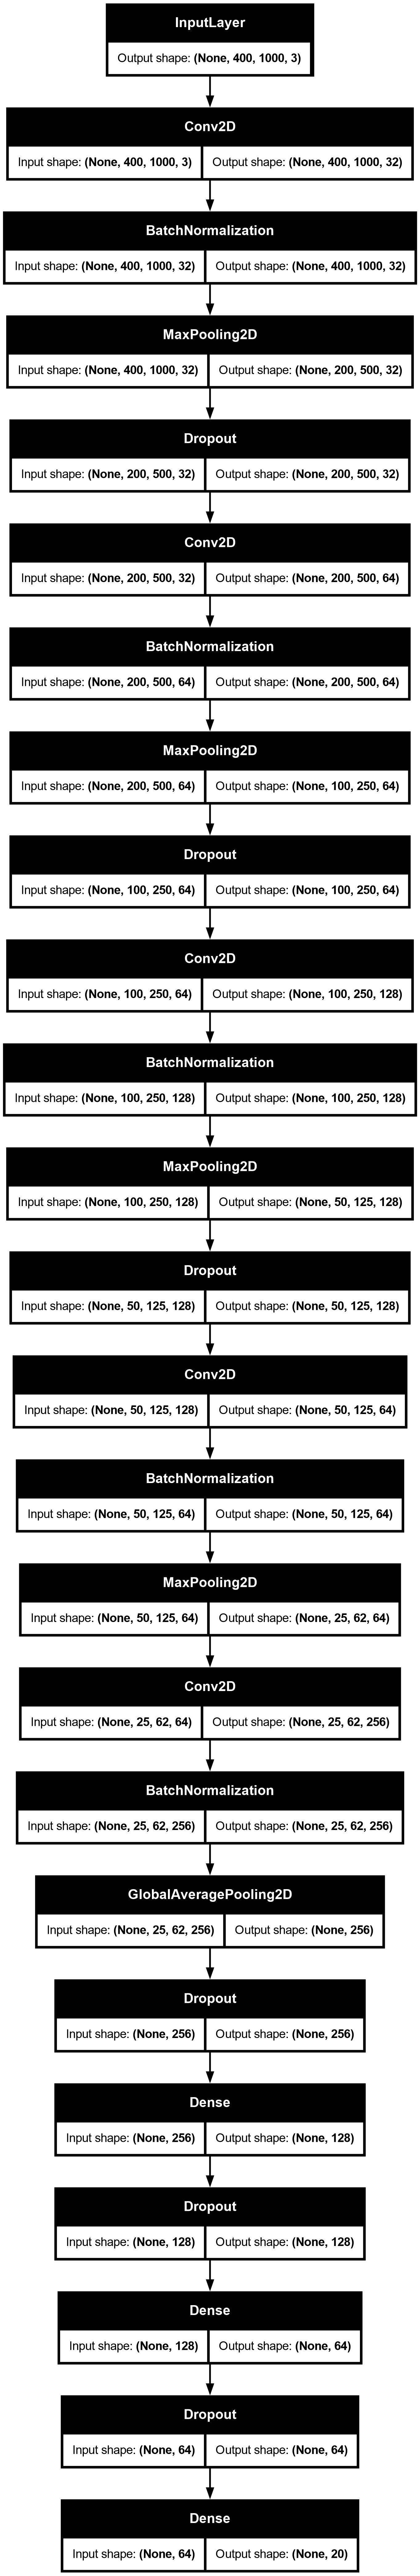

In [33]:
plot_model(FCNNModel, show_shapes=True)


In [ ]:
historyFCNN = FCNNModel.fit(x_train_FCNN, y_train_FCNN, validation_data=(x_test_FCNN, y_test_FCNN), epochs=100, batch_size=16, callbacks=[checkpointer, monitor])


Epoch 1/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 2244s 8s/step - accuracy: 0.0910 - loss: 2.9441 - val_accuracy: 0.0429 - val_loss: 3.0789
Epoch 2/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 1794s 7s/step - accuracy: 0.1087 - loss: 2.8926 - val_accuracy: 0.1063 - val_loss: 3.1010
Epoch 3/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 1997s 7s/step - accuracy: 0.1272 - loss: 2.8598 - val_accuracy: 0.1063 - val_loss: 2.9725
Epoch 4/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 1985s 7s/step - accuracy: 0.1328 - loss: 2.8368 - val_accuracy: 0.1054 - val_loss: 2.9740
Epoch 5/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 1848s 7s/step - accuracy: 0.1398 - loss: 2.8149 - val_accuracy: 0.1157 - val_loss: 2.9300
Epoch 6/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 1767s 7s/step - accuracy: 0.1489 - loss: 2.7953 - val_accuracy: 0.1269 - val_loss: 3.0166
Epoch 7/100
188/268 ━━━━━━━━━━━━━━━━━━━━ 9:04 7s/step - accuracy: 0.1501 - loss: 2.7488

KeyboardInterrupt: 

: 

In [189]:
plot_losses(historyFCNN, iteration_string, ITERATION, "FCNN" )


## GRU-CNN Hybrid Model

In [41]:
full_path = iteration_path #path to current iteration directory to save weights
checkpointer = ModelCheckpoint(filepath=os.path.join(full_path, "best_GRUweights.keras"), verbose=0, save_best_only=True) #save best model
optimizer = Adam(learning_rate = 0.0001)
input_shape = (400,1000,3) #input shape H,W,Channels
num_classes = 20 #num_classes = classes to predict

inputs = layers.Input(shape=input_shape)
#CNN
#block 1
x = layers.Conv2D(32, kernel_size=3, activation='relu', padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

#block 2
x = layers.Conv2D(64, kernel_size=3, activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

#block 3
x = layers.Conv2D(128, kernel_size=3, activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

#block 4
x = layers.Conv2D(64, 1, activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

#reshape for the LSTM
# -> (time, features)
shape = x.shape
x = layers.Reshape((shape[2], shape[1] * shape[3]))(x)

#LSTM for time modeling
x = layers.Bidirectional(layers.GRU(128, return_sequences=True))(x) #output (62,128)
x = layers.Dropout(0.3)(x)
x = layers.LSTM(64, return_sequences=False)(x) #output (128)
x = layers.Dropout(0.3)(x)

#dense layers for classification
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.4)(x)

#output layer (variable number of classes to predict)
outputs = layers.Dense(num_classes, activation='softmax')(x)

#create the model
GRUModel = Model(inputs=inputs, outputs=outputs)

#model compilation
GRUModel.compile(optimizer=optimizer, loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05), metrics=["accuracy"])

monitor = EarlyStopping(monitor='val_loss', min_delta=1e-3, patience=5, verbose=2, mode='min', restore_best_weights=True)



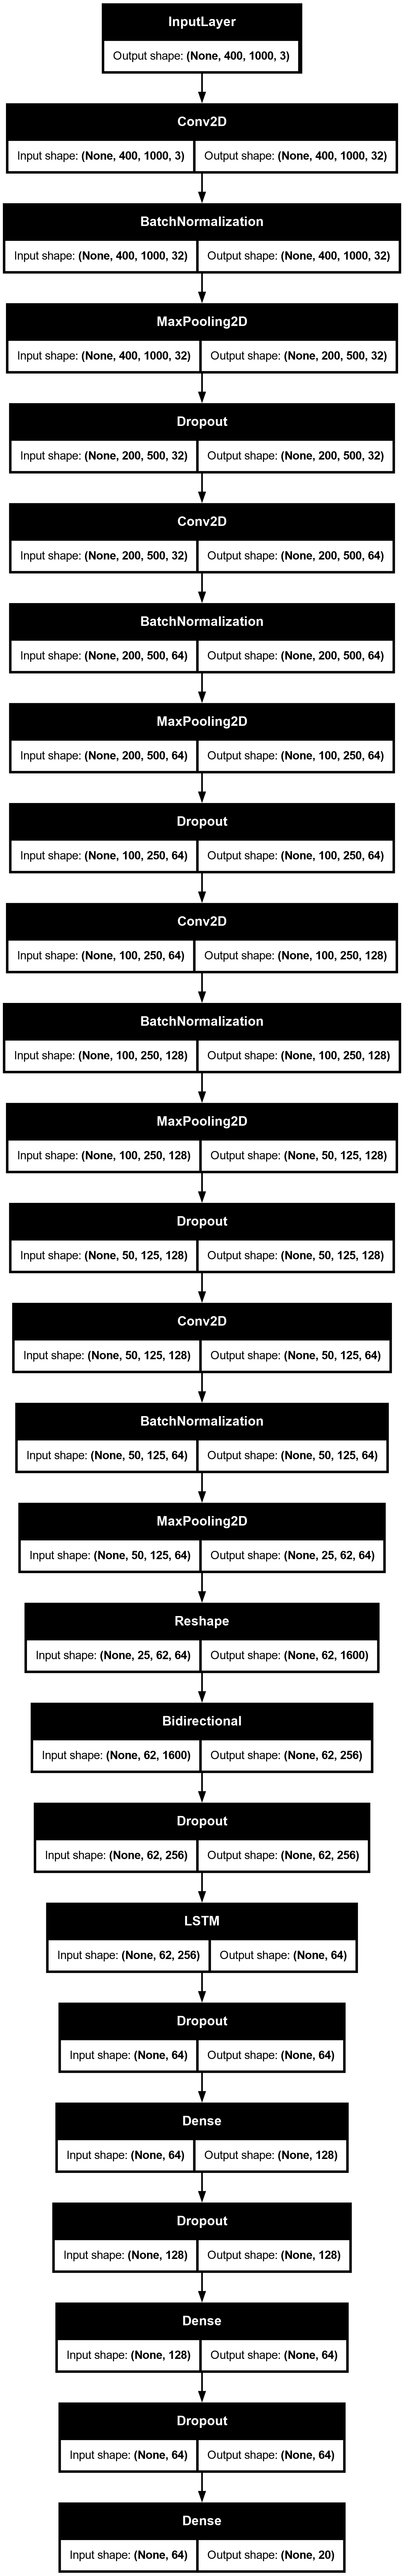

In [42]:
plot_model(GRUModel, show_shapes=True)


In [ ]:
history = GRUModel.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=100, batch_size=16, callbacks=[checkpointer, monitor])



Epoch 1/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 183s 684ms/step - accuracy: 0.0560 - loss: 3.0018 - val_accuracy: 0.0504 - val_loss: 3.0151
Epoch 2/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 171s 638ms/step - accuracy: 0.0723 - loss: 2.9718 - val_accuracy: 0.0476 - val_loss: 2.9693
Epoch 3/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 183s 683ms/step - accuracy: 0.0691 - loss: 2.9558 - val_accuracy: 0.1054 - val_loss: 2.9433
Epoch 4/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 180s 672ms/step - accuracy: 0.0817 - loss: 2.9474 - val_accuracy: 0.1063 - val_loss: 2.9437
Epoch 5/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 181s 674ms/step - accuracy: 0.0828 - loss: 2.9375 - val_accuracy: 0.0914 - val_loss: 2.9371
Epoch 6/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 183s 684ms/step - accuracy: 0.0854 - loss: 2.9139 - val_accuracy: 0.1175 - val_loss: 2.9159
Epoch 7/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 180s 670ms/step - accuracy: 0.0926 - loss: 2.8828 - val_accuracy: 0.1035 - val_loss: 2.8954
Epoch 8/100
268/268 ━━━━━━━━━━━━━━━━━━━━ 181s 676ms/step - accuracy: 

## LSTM-CNN Hybrid Model

In [43]:
full_path = iteration_path #path to current iteration directory to save weights
checkpointer = ModelCheckpoint(filepath=os.path.join(full_path, "best_GRUweights.keras"), verbose=0, save_best_only=True) #save best model
optimizer = Adam(learning_rate = 0.0001)
input_shape = (400,1000,3) #input shape H,W,Channels
num_classes = 20 #num_classes = classes to predict

inputs = layers.Input(shape=input_shape)
#CNN
#block 1
x = layers.Conv2D(32, kernel_size=3, activation='relu', padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

#block 2
x = layers.Conv2D(64, kernel_size=3, activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

#block 3
x = layers.Conv2D(128, kernel_size=3, activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

#block 4
x = layers.Conv2D(64, 1, activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

#reshape for the LSTM
# -> (time, features)
shape = x.shape
x = layers.Reshape((shape[2], shape[1] * shape[3]))(x)

#LSTM for time modeling
x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x) #output (62,128)
x = layers.Dropout(0.3)(x)
x = layers.LSTM(64, return_sequences=False)(x) #output (128)
x = layers.Dropout(0.3)(x)

#dense layers for classification
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.4)(x)

#output layer (variable number of classes to predict)
outputs = layers.Dense(num_classes, activation='softmax')(x)

#create the model
model = Model(inputs=inputs, outputs=outputs)

#model compilation
model.compile(optimizer=optimizer, loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05), metrics=["accuracy"])

monitor = EarlyStopping(monitor='val_loss', min_delta=1e-3, patience=5, verbose=2, mode='min', restore_best_weights=True)


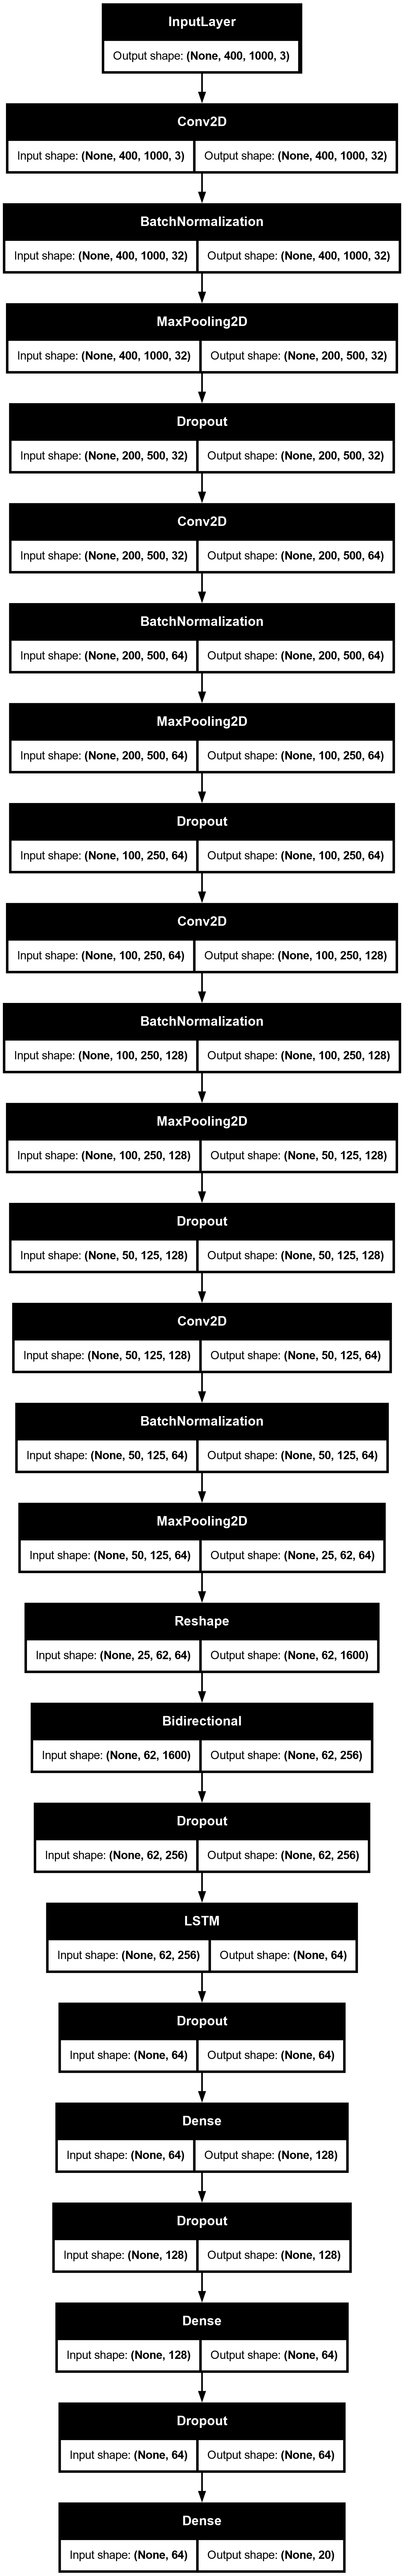

In [44]:
plot_model(model, show_shapes=True)


In [ ]:
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=100, batch_size=16, callbacks=[checkpointer, monitor])


In [194]:
iteration_string = f"./output/iteration-{ITERATION}"
plot_losses(history, iteration_string, "GRU-1", "GRU" )


In [195]:

import numpy as np
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, log_loss, top_k_accuracy_score)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
full_path = "./output/iteration-6/"


# Plot confusion matrix
def plot_confusion_matrix(cm, names, title='Confusion matrix', cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(names))
    plt.xticks(tick_marks, names, rotation=45)
    plt.yticks(tick_marks, names)
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
#load best weights
iteration_string = f"iteration-{ITERATION}"
model.load_weights(os.path.join(output_path, iteration_string, "best_GRUweights.keras"))
print("weights loaded successfully")


#make the predictions
prediction = model.predict(x_test, verbose=1)
y_true = np.argmax(y_test, axis=1)
pred = np.argmax(prediction, axis=1)

#note: there may be some warnings based on some inputs not having
#any test or train samples, feel free to ignore these for now
bird_species_names = sorted(modelDF["Bird-Species"].unique())
from sklearn import metrics
#calculate metrics, save as txt
try:
    #save path in iteration directory
    metrics_path = os.path.join(output_path, iteration_string, 'metricsGRU.txt')
    
    with open(metrics_path, 'w') as file:
        accuracy_score = metrics.accuracy_score(y_true, pred)
        precision_score = metrics.precision_score(y_true, pred, average='weighted')
        recall_score = metrics.recall_score(y_true, pred, average="weighted")
        f1_score = metrics.f1_score(y_true, pred, average="weighted")
        
        #evaluate the standard metrics
        file.write("="*60 + "\n")
        file.write("MODEL EVALUATION METRICS\n")
        file.write("="*60 + "\n\n")
        
        file.write(f"Accuracy Score: {accuracy_score:.4f} ({accuracy_score*100:.2f}%)\n")
        file.write(f"Precision Score: {precision_score:.4f}\n")
        file.write(f"Recall Score: {recall_score:.4f}\n")
        file.write(f"F1 Score: {f1_score:.4f}\n\n")

        #log loss
        log_loss_score = metrics.log_loss(y_true, prediction, labels=list(range(num_classes)))
        file.write(f"Log Loss: {log_loss_score:.4f}\n\n")
        print(f"Log loss score: {log_loss_score:.4f}\n")
        
        #classification report
        file.write("="*60 + "\n")
        file.write("PER-CLASS PERFORMANCE\n")
        file.write("="*60 + "\n\n")
        
        file.write(metrics.classification_report(y_true, pred, 
                                                 target_names=bird_species_names,
                                                 digits=4,
                                                 labels=list(range(41))))
        
        #sample predictions
        file.write("\n\n" + "="*60 + "\n")
        file.write("SAMPLE PREDICTIONS\n")
        file.write("="*60 + "\n\n")
        
        file.write("First 5 predictions:\n")
        file.write(np.array_str(pred[0:5]))
        file.write("\n\nFirst 5 true labels:\n")
        file.write(np.array_str(y_true[0:5]))
        
        #add bird species names for first 5 predictions
        file.write("\n\nFirst 5 predictions (bird names):\n")
        for i in range(min(5, len(pred))):
            file.write(f"  Sample {i+1}: Predicted={bird_species_names[pred[i]]}, "
                      f"True={bird_species_names[y_true[i]]}\n")
        
    print(f"Metrics saved to: {metrics_path}")
    
except OSError as e:
    print(f"Error while writing model metrics:\n{e}")
    
#plot confusion matrix
try:
    cm = confusion_matrix(y_true, pred)
    plt.figure(figsize=(16, 14))
    plot_confusion_matrix(cm, bird_species_names, 
                         title='Confusion Matrix - Bird Species Classification',
                         cmap=plt.cm.Blues)
    
    #fix for x tick overlap & adjust title size
    plt.xticks(fontsize=9, rotation=90)
    plt.title('Confusion Matrix - Bird Species Classification', fontsize=18, pad=20)
    plt.tight_layout()
    
    #save to the iteration directory
    save_path = os.path.join(output_path, iteration_string, 'cnn-lstm-confusion-matrix.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Confusion matrix saved to: {save_path}")
    plt.close()
    
except Exception as e:
    print(f"Error creating confusion matrix plot:\n{e}")


weights loaded successfully
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 355ms/step
Log loss score: 2.6233

Metrics saved to: c:\Users\snowt\OneDrive\Documents\CSC-180\finalProject\bird-song-recognizer\output\iteration-6\metricsGRU.txt


c:\Users\snowt\anaconda3\envs\keras-torch\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\snowt\anaconda3\envs\keras-torch\Lib\site-packages\sklearn\metrics\_classification.py:2964: UserWarning: labels size, 41, does not match size of target_names, 20
  warnings.warn(
c:\Users\snowt\anaconda3\envs\keras-torch\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\snowt\anaconda3\envs\keras-torch\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recal

Confusion matrix saved to: c:\Users\snowt\OneDrive\Documents\CSC-180\finalProject\bird-song-recognizer\output\iteration-6\cnn-lstm-confusion-matrix.png


In [ ]:
if(not GLOBAL_DISABLE):
    import numpy as np
    from sklearn.metrics import (classification_report, confusion_matrix, 
                                accuracy_score, log_loss, top_k_accuracy_score)
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import classification_report, confusion_matrix
    import numpy as np
    full_path = "./output/iteration-6/"


    # Plot confusion matrix
    def plot_confusion_matrix(cm, names, title='Confusion matrix', cmap=plt.cm.Blues):
        plt.imshow(cm, interpolation='nearest', cmap=cmap)
        plt.title(title)
        plt.colorbar()
        tick_marks = np.arange(len(names))
        plt.xticks(tick_marks, names, rotation=45)
        plt.yticks(tick_marks, names)
        plt.tight_layout()
        plt.ylabel('True label')
        plt.xlabel('Predicted label')

    #needs model, file name, weight name, weight name, model type, x_test/train, y_test/train, and any others you come across
    def export_metrics(cur_model, cur_x_test, cur_x_train, cur_y_test, cur_y_train, cur_weight_name): 
        #load best weights
        iteration_string = f"iteration-{ITERATION}"
        model.load_weights(os.path.join(output_path, iteration_string, cur_weight_name))
        print("weights loaded successfully")


        #make the predictions
        prediction = cur_model.predict(x_test, verbose=1)
        y_true = np.argmax(y_test, axis=1)
        pred = np.argmax(prediction, axis=1)

        #note: there may be some warnings based on some inputs not having
        #any test or train samples, feel free to ignore these for now
        bird_species_names = sorted(modelDF["Bird-Species"].unique())
        from sklearn import metrics
        #calculate metrics, save as txt
        try:
            #save path in iteration directory
            metrics_path = os.path.join(output_path, iteration_string, 'metrics.txt')
            
            with open(metrics_path, 'w') as file:
                accuracy_score = metrics.accuracy_score(y_true, pred)
                precision_score = metrics.precision_score(y_true, pred, average='weighted')
                recall_score = metrics.recall_score(y_true, pred, average="weighted")
                f1_score = metrics.f1_score(y_true, pred, average="weighted")
                
                #evaluate the standard metrics
                file.write("="*60 + "\n")
                file.write("MODEL EVALUATION METRICS\n")
                file.write("="*60 + "\n\n")
                
                file.write(f"Accuracy Score: {accuracy_score:.4f} ({accuracy_score*100:.2f}%)\n")
                file.write(f"Precision Score: {precision_score:.4f}\n")
                file.write(f"Recall Score: {recall_score:.4f}\n")
                file.write(f"F1 Score: {f1_score:.4f}\n\n")

                #log loss
                log_loss_score = metrics.log_loss(y_true, prediction, labels=list(range(num_classes)))
                file.write(f"Log Loss: {log_loss_score:.4f}\n\n")
                print(f"Log loss score: {log_loss_score:.4f}\n")
                
                #classification report
                file.write("="*60 + "\n")
                file.write("PER-CLASS PERFORMANCE\n")
                file.write("="*60 + "\n\n")
                
                file.write(metrics.classification_report(y_true, pred, 
                                                        target_names=bird_species_names,
                                                        digits=4,
                                                        labels=list(range(41))))
                
                #sample predictions
                file.write("\n\n" + "="*60 + "\n")
                file.write("SAMPLE PREDICTIONS\n")
                file.write("="*60 + "\n\n")
                
                file.write("First 5 predictions:\n")
                file.write(np.array_str(pred[0:5]))
                file.write("\n\nFirst 5 true labels:\n")
                file.write(np.array_str(y_true[0:5]))
                
                #add bird species names for first 5 predictions
                file.write("\n\nFirst 5 predictions (bird names):\n")
                for i in range(min(5, len(pred))):
                    file.write(f"  Sample {i+1}: Predicted={bird_species_names[pred[i]]}, "
                            f"True={bird_species_names[y_true[i]]}\n")
                
            print(f"Metrics saved to: {metrics_path}")
            
        except OSError as e:
            print(f"Error while writing model metrics:\n{e}")
            
        #plot confusion matrix
        try:
            cm = confusion_matrix(y_true, pred)
            plt.figure(figsize=(16, 14))
            plot_confusion_matrix(cm, bird_species_names, 
                                title='Confusion Matrix - Bird Species Classification',
                                cmap=plt.cm.Blues)
            
            #fix for x tick overlap & adjust title size
            plt.xticks(fontsize=9, rotation=90)
            plt.title('Confusion Matrix - Bird Species Classification', fontsize=18, pad=20)
            plt.tight_layout()
            
            #save to the iteration directory
            save_path = os.path.join(output_path, iteration_string, 'cnn-lstm-confusion-matrix.png')
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Confusion matrix saved to: {save_path}")
            plt.close()
            
        except Exception as e:
            print(f"Error creating confusion matrix plot:\n{e}")


In [207]:
calculateMetrics("best_FCNNweights.keras", x_test_FCNN, y_test_FCNN, "metricsFCNN.txt", FCNNModel)
plotConfusionMatrix("best_FCNNweights.keras", x_test_FCNN, y_test_FCNN, "FCNN-Confusion-Matrix.png", FCNNModel)

weights loaded successfully
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step
Log loss score: 2.9612

Metrics saved to: c:\Users\snowt\OneDrive\Documents\CSC-180\finalProject\bird-song-recognizer\output\iteration-6\metricsFCNN.txt
weights loaded successfully


c:\Users\snowt\anaconda3\envs\keras-torch\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\snowt\anaconda3\envs\keras-torch\Lib\site-packages\sklearn\metrics\_classification.py:2964: UserWarning: labels size, 41, does not match size of target_names, 20
  warnings.warn(
c:\Users\snowt\anaconda3\envs\keras-torch\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\snowt\anaconda3\envs\keras-torch\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recal

34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step
Confusion matrix saved to: c:\Users\snowt\OneDrive\Documents\CSC-180\finalProject\bird-song-recognizer\output\iteration-6\FCNN-Confusion-Matrix.png


FCNN Confusion Matrix


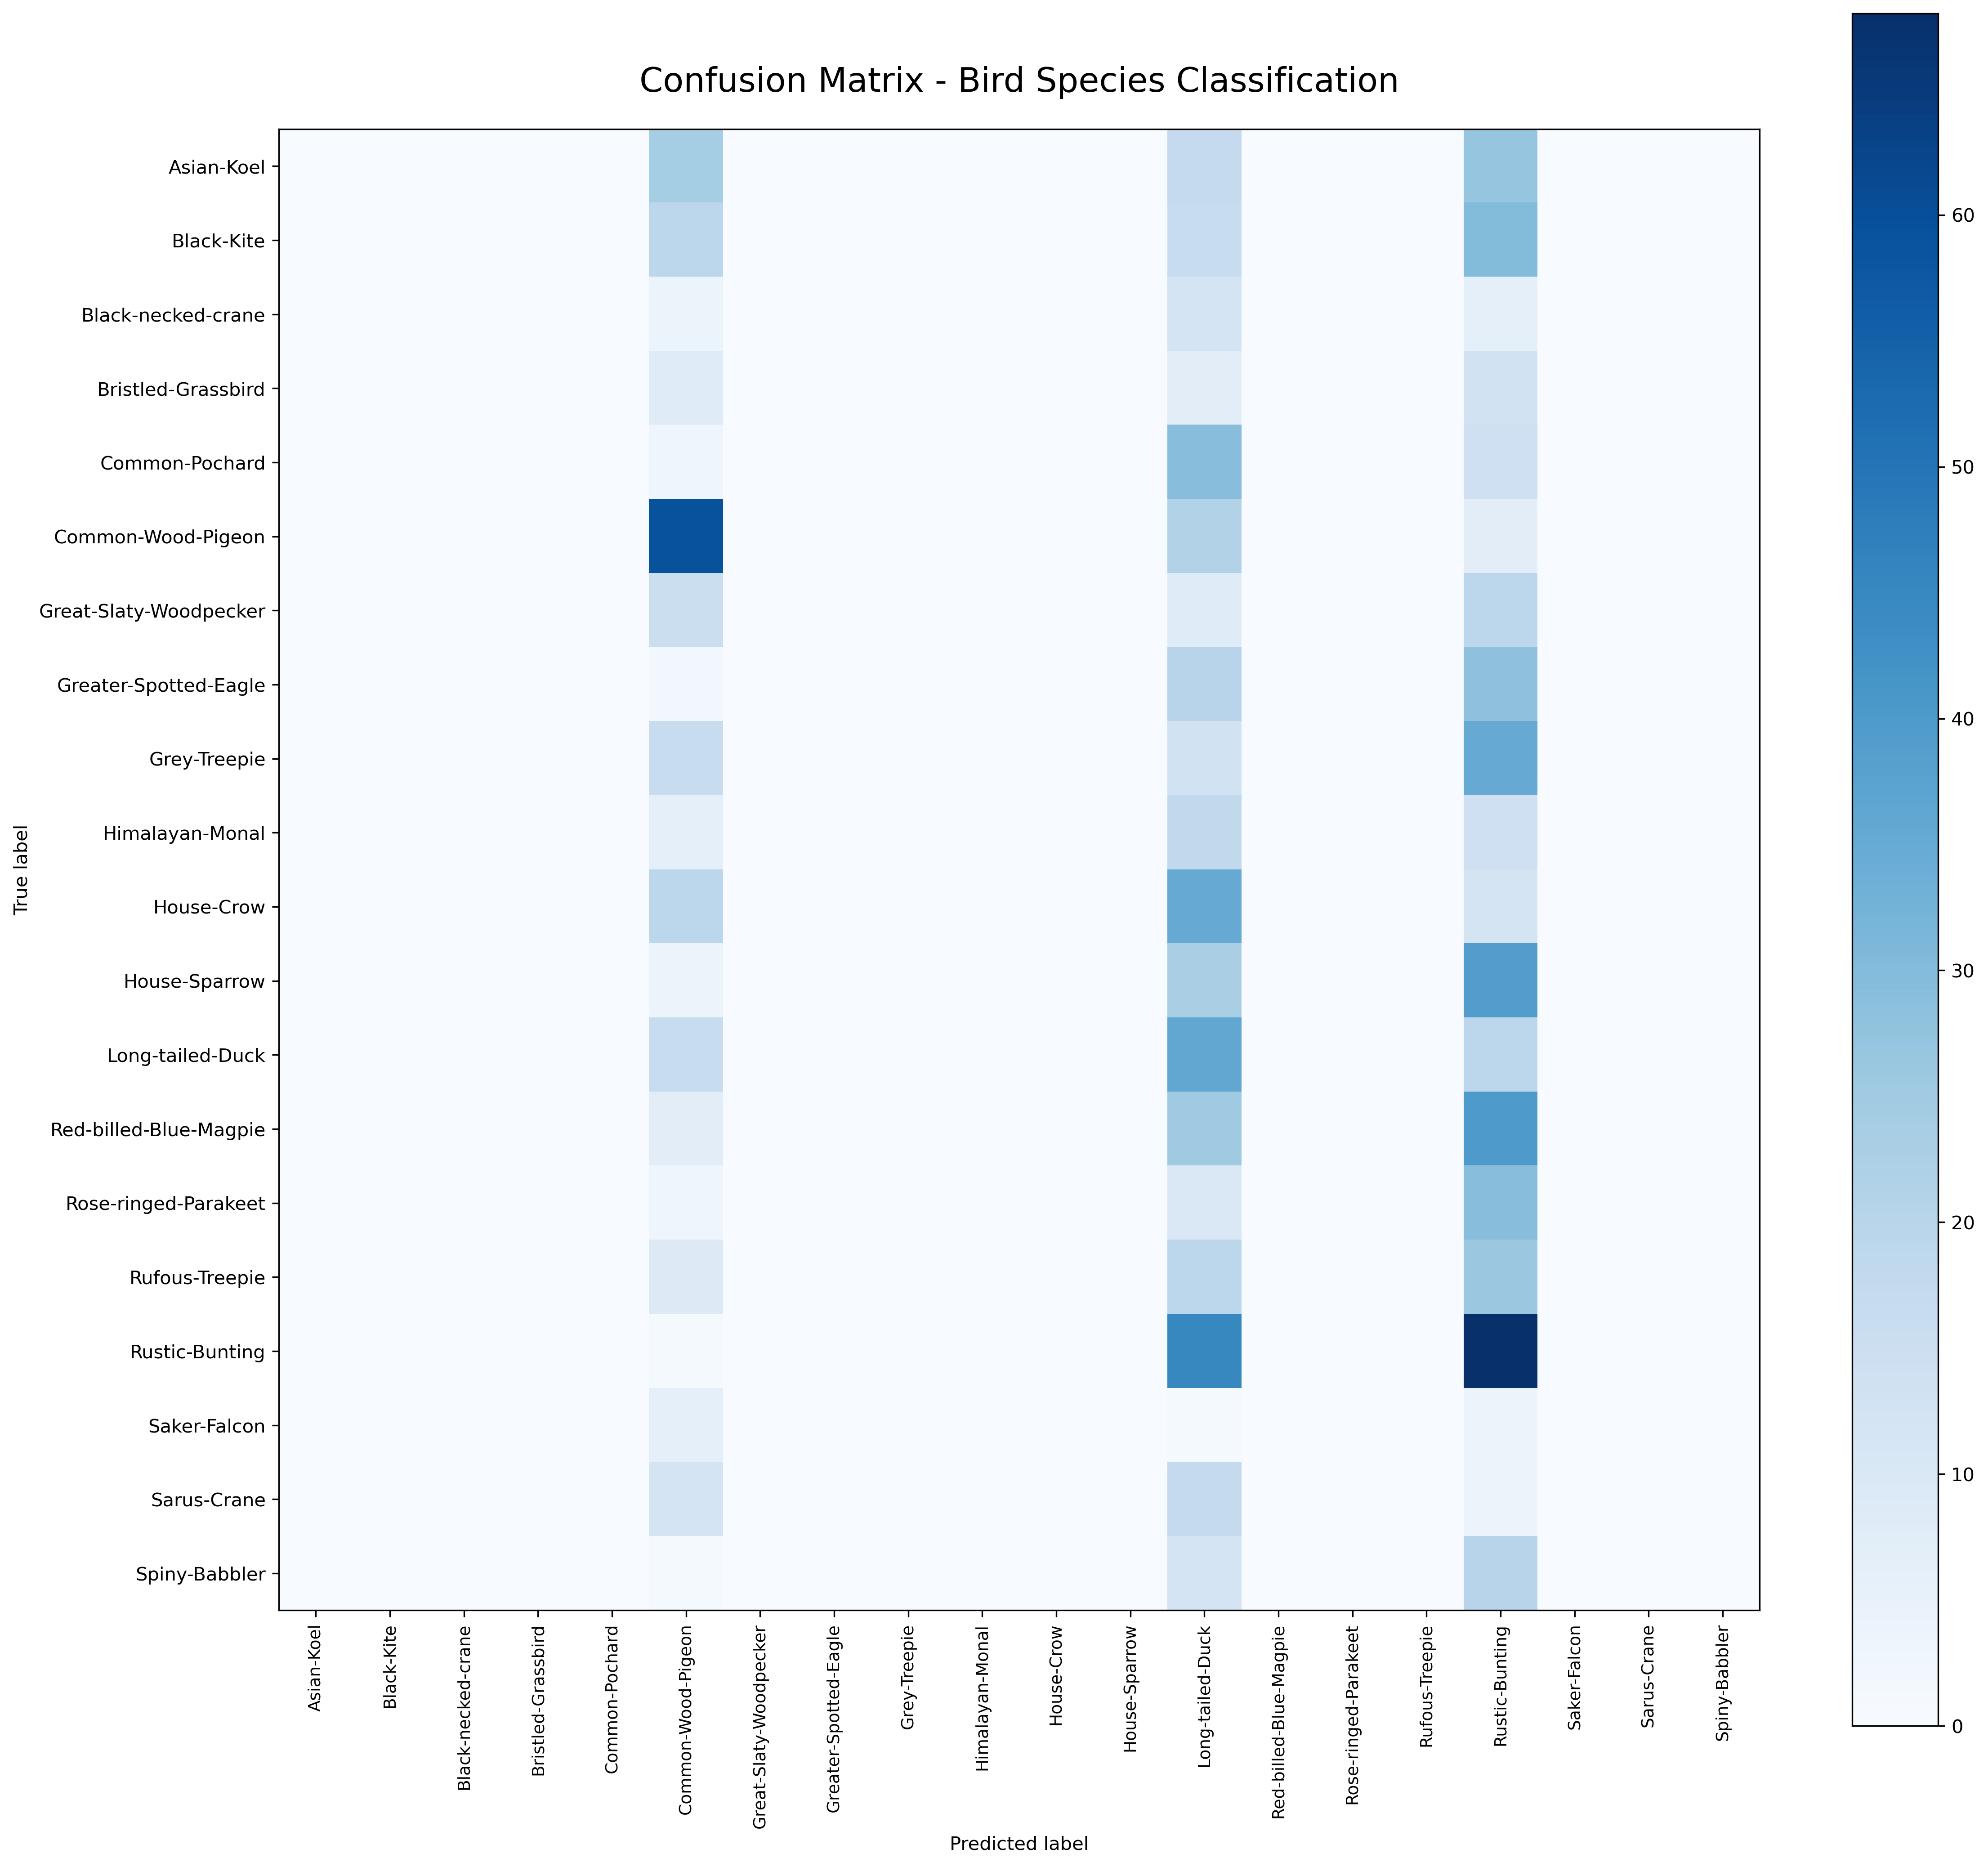

MODEL EVALUATION METRICS

Accuracy Score: 0.1521 (15.21%)
Precision Score: 0.0426
Recall Score: 0.1521
F1 Score: 0.0658

Log Loss: 2.9612

PER-CLASS PERFORMANCE

                        precision    recall  f1-score   support

            Asian-Koel     0.0000    0.0000    0.0000        68
            Black-Kite     0.0000    0.0000    0.0000        65
    Black-necked-crane     0.0000    0.0000    0.0000        22
    Bristled-Grassbird     0.0000    0.0000    0.0000        28
        Common-Pochard     0.0000    0.0000    0.0000        46
    Common-Wood-Pigeon     0.2521    0.6782    0.3676        87
Great-Slaty-Woodpecker     0.0000    0.0000    0.0000        42
 Greater-Spotted-Eagle     0.0000    0.0000    0.0000        50
          Grey-Treepie     0.0000    0.0000    0.0000        64
       Himalayan-Monal     0.0000    0.0000    0.0000        38
            House-Crow     0.0000    0.0000    0.0000        66
         House-Sparrow     0.0000    0.0000    0.0000        66
     

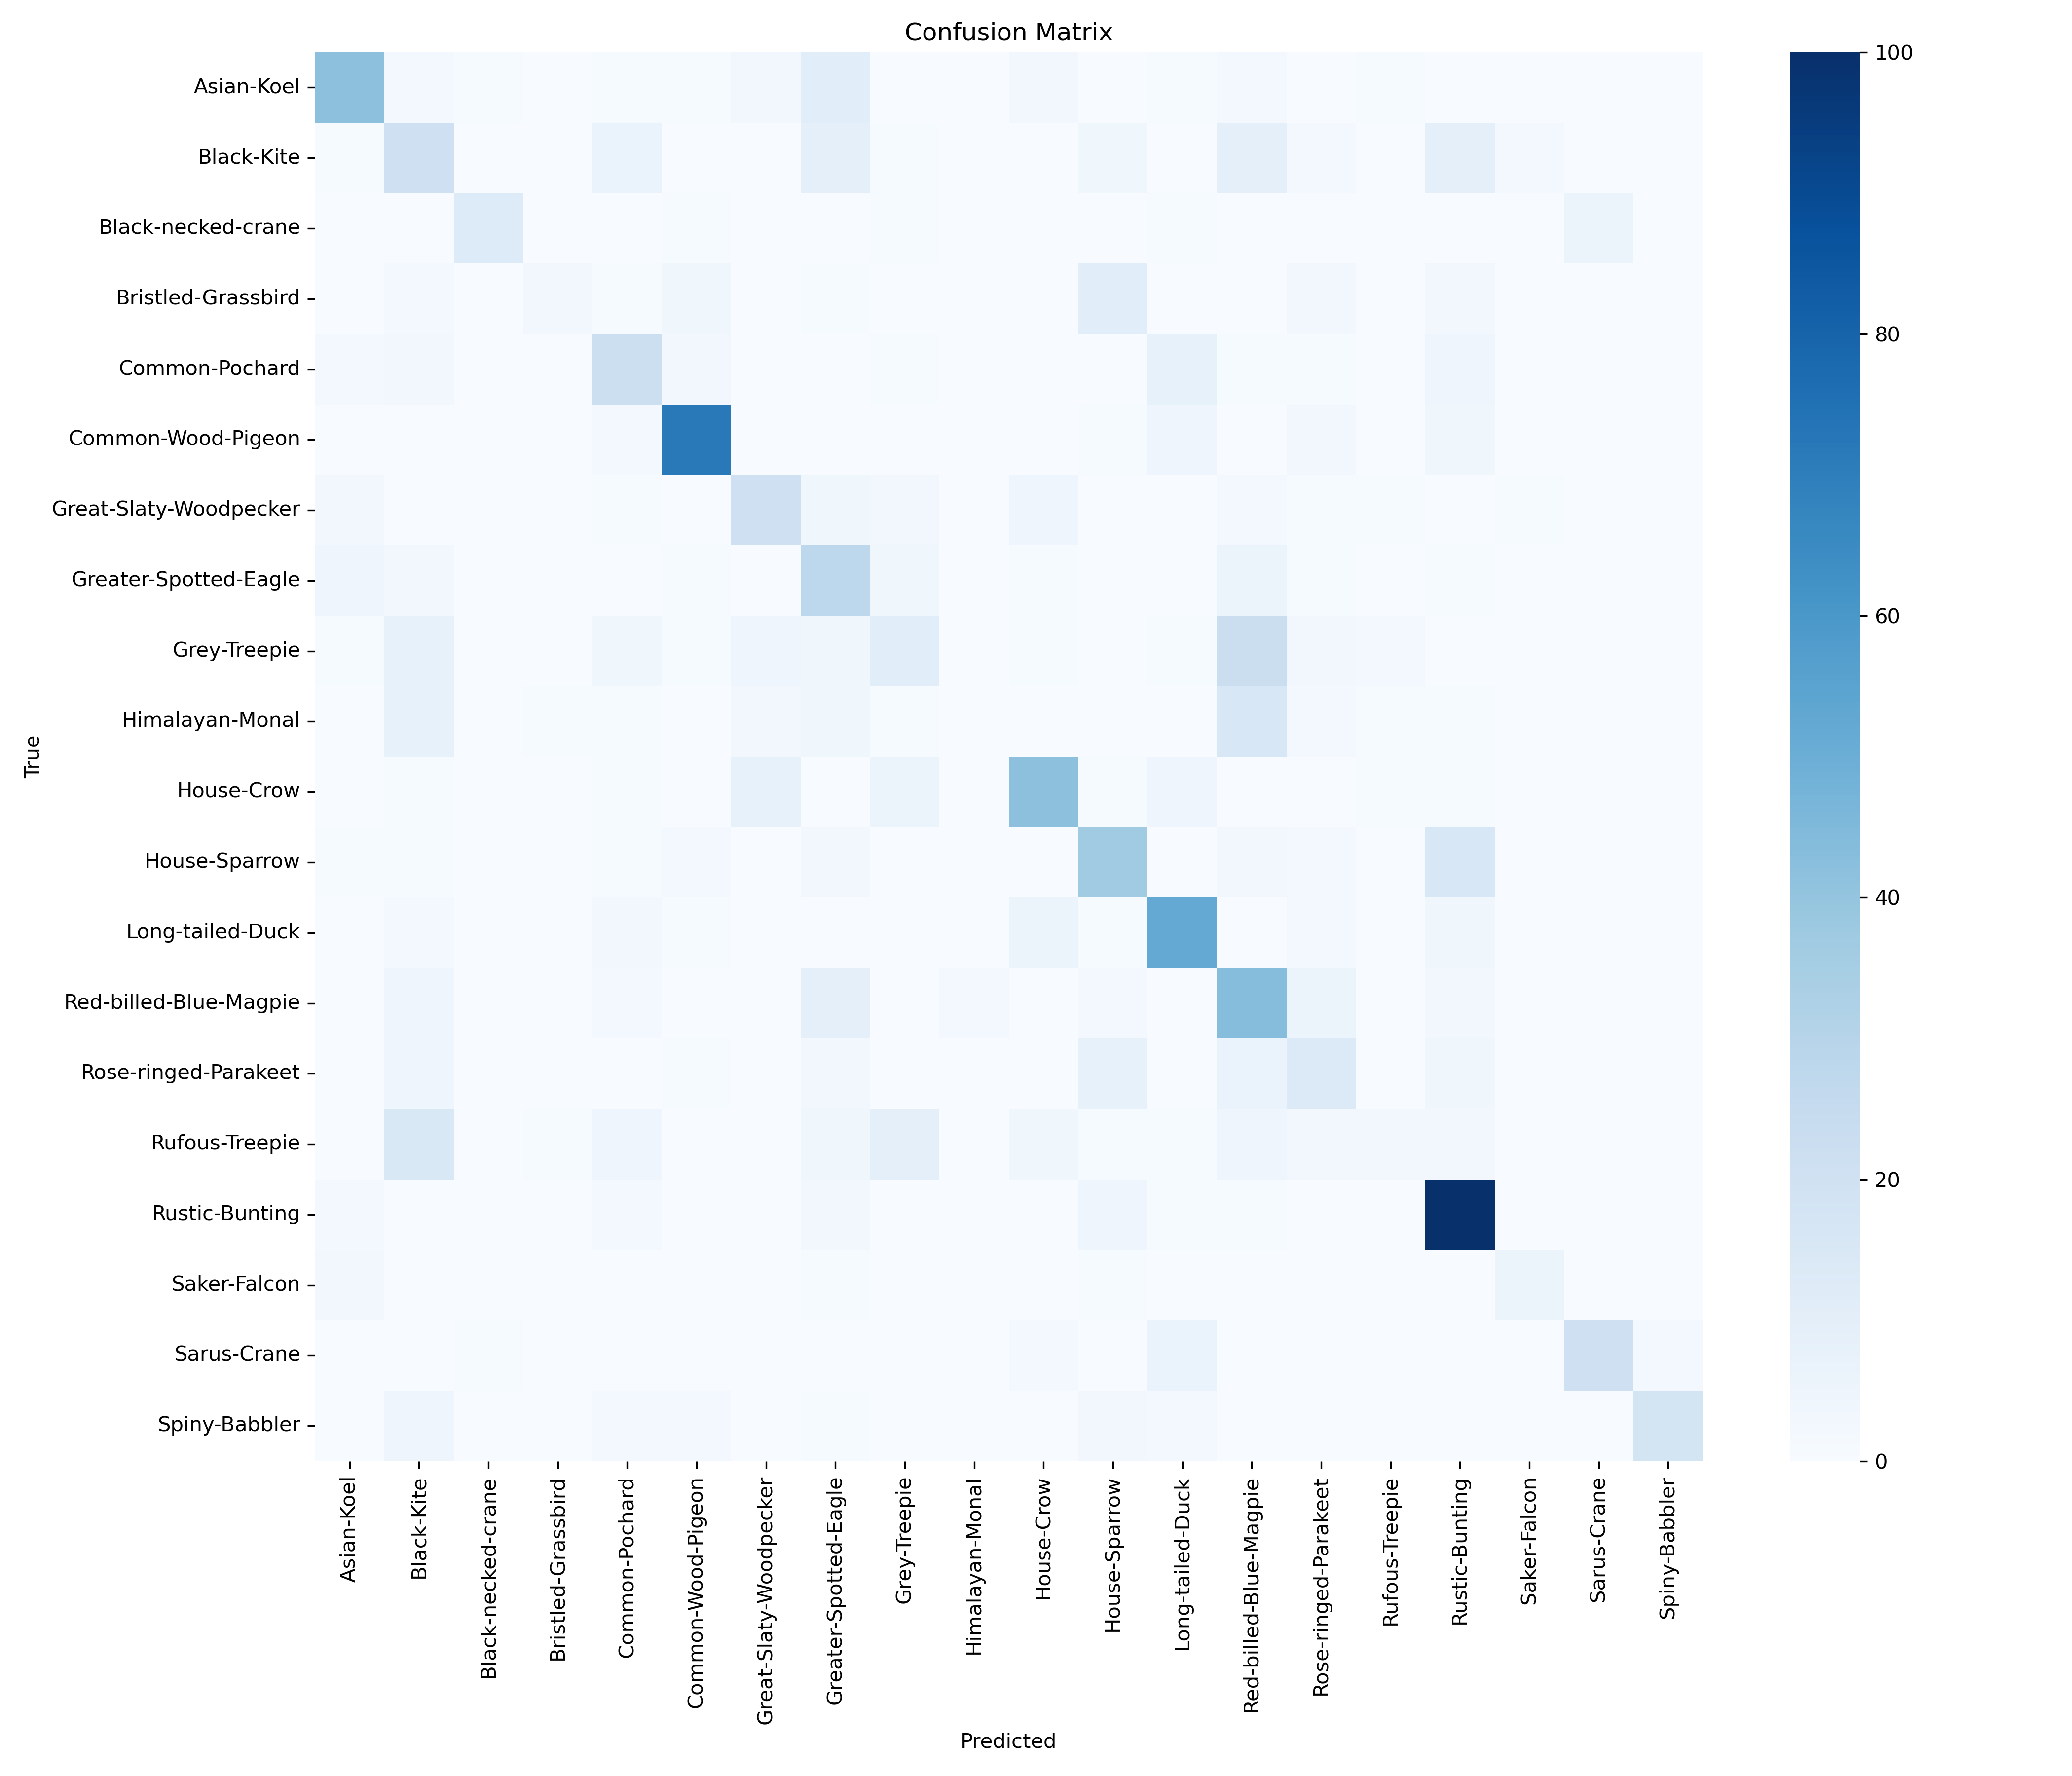

MODEL EVALUATION METRICS

Accuracy Score: 0.5308 (53.08%)
Precision Score: 0.5234
Recall Score: 0.5308
F1 Score: 0.5084

Log Loss: 1.6227

PER-CLASS PERFORMANCE

                        precision    recall  f1-score   support

            Asian-Koel     0.7000    0.6176    0.6562        68
            Black-Kite     0.2593    0.3231    0.2877        65
    Black-necked-crane     0.8667    0.5909    0.7027        22
    Bristled-Grassbird     0.6000    0.1071    0.1818        28
        Common-Pochard     0.4000    0.4783    0.4356        46
    Common-Wood-Pigeon     0.8090    0.8276    0.8182        87
Great-Slaty-Woodpecker     0.5250    0.5000    0.5122        42
 Greater-Spotted-Eagle     0.3294    0.5600    0.4148        50
          Grey-Treepie     0.2973    0.1719    0.2178        64
       Himalayan-Monal     0.0000    0.0000    0.0000        38
            House-Crow     0.6562    0.6364    0.6462        66
         House-Sparrow     0.4933    0.5606    0.5248        66
     

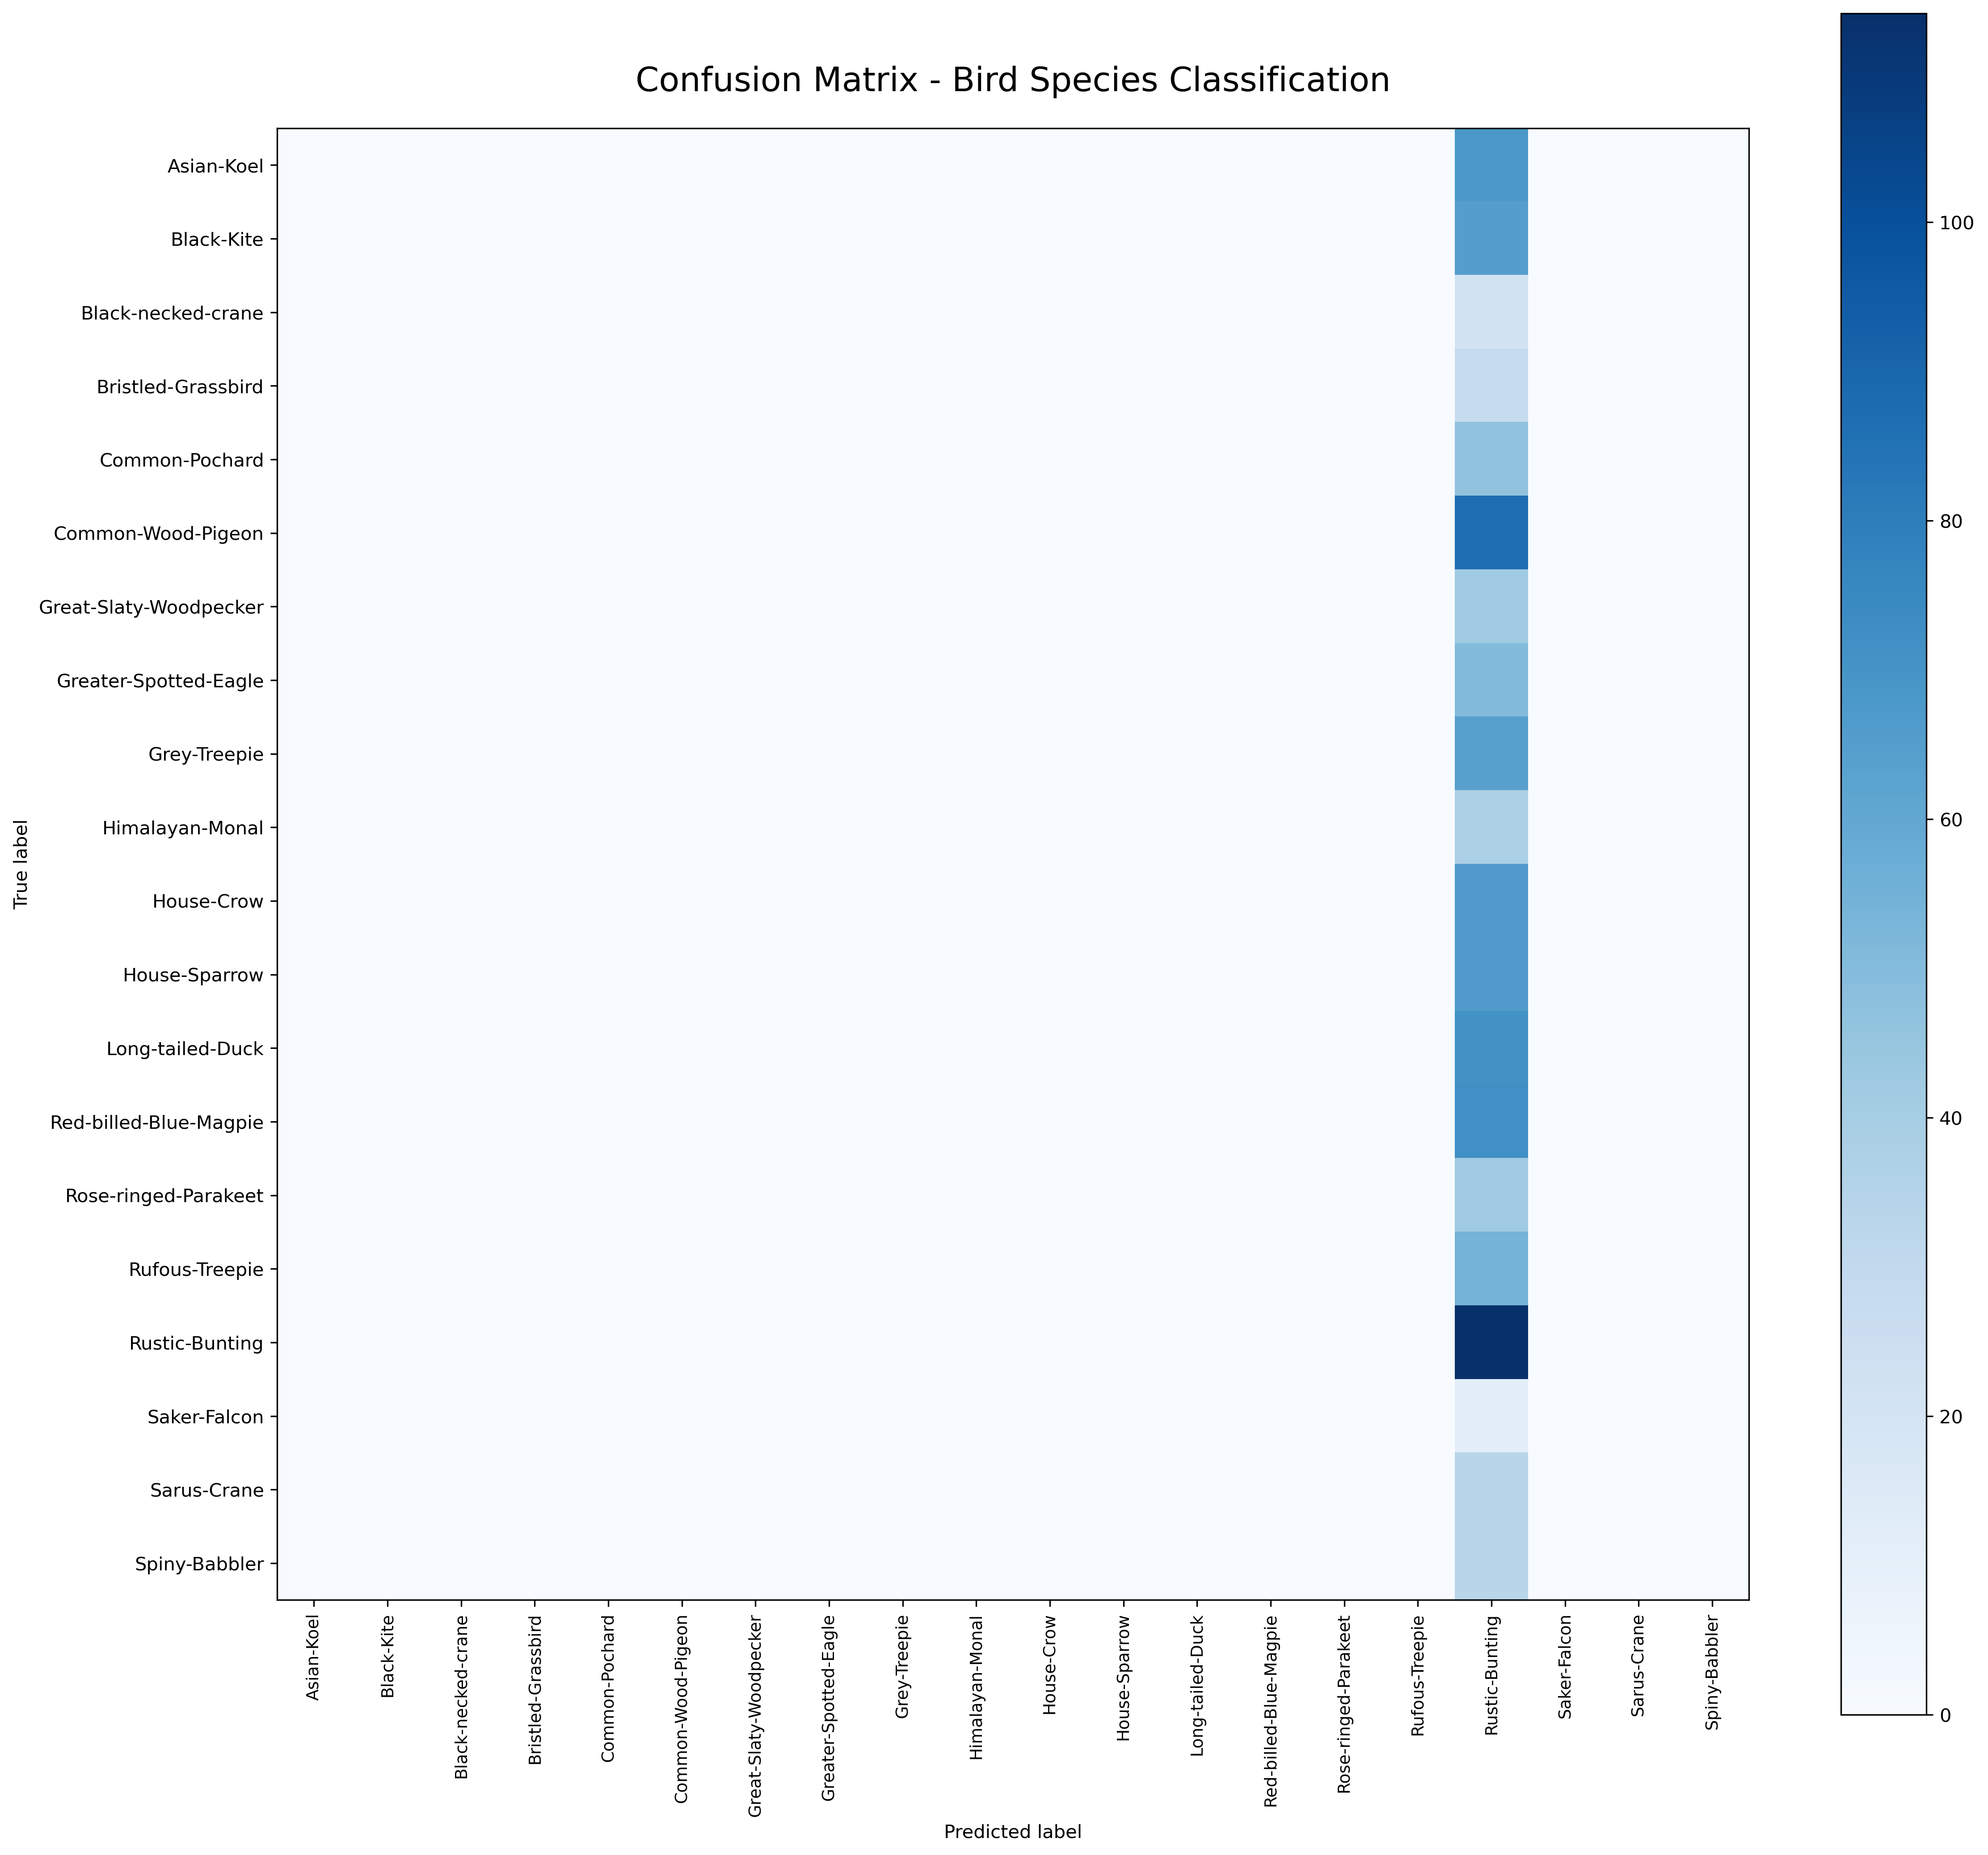

MODEL EVALUATION METRICS

Accuracy Score: 0.1063 (10.63%)
Precision Score: 0.0113
Recall Score: 0.1063
F1 Score: 0.0204

Log Loss: 2.9105

PER-CLASS PERFORMANCE

                        precision    recall  f1-score   support

            Asian-Koel     0.0000    0.0000    0.0000        68
            Black-Kite     0.0000    0.0000    0.0000        65
    Black-necked-crane     0.0000    0.0000    0.0000        22
    Bristled-Grassbird     0.0000    0.0000    0.0000        28
        Common-Pochard     0.0000    0.0000    0.0000        46
    Common-Wood-Pigeon     0.0000    0.0000    0.0000        87
Great-Slaty-Woodpecker     0.0000    0.0000    0.0000        42
 Greater-Spotted-Eagle     0.0000    0.0000    0.0000        50
          Grey-Treepie     0.0000    0.0000    0.0000        64
       Himalayan-Monal     0.0000    0.0000    0.0000        38
            House-Crow     0.0000    0.0000    0.0000        66
         House-Sparrow     0.0000    0.0000    0.0000        66
     

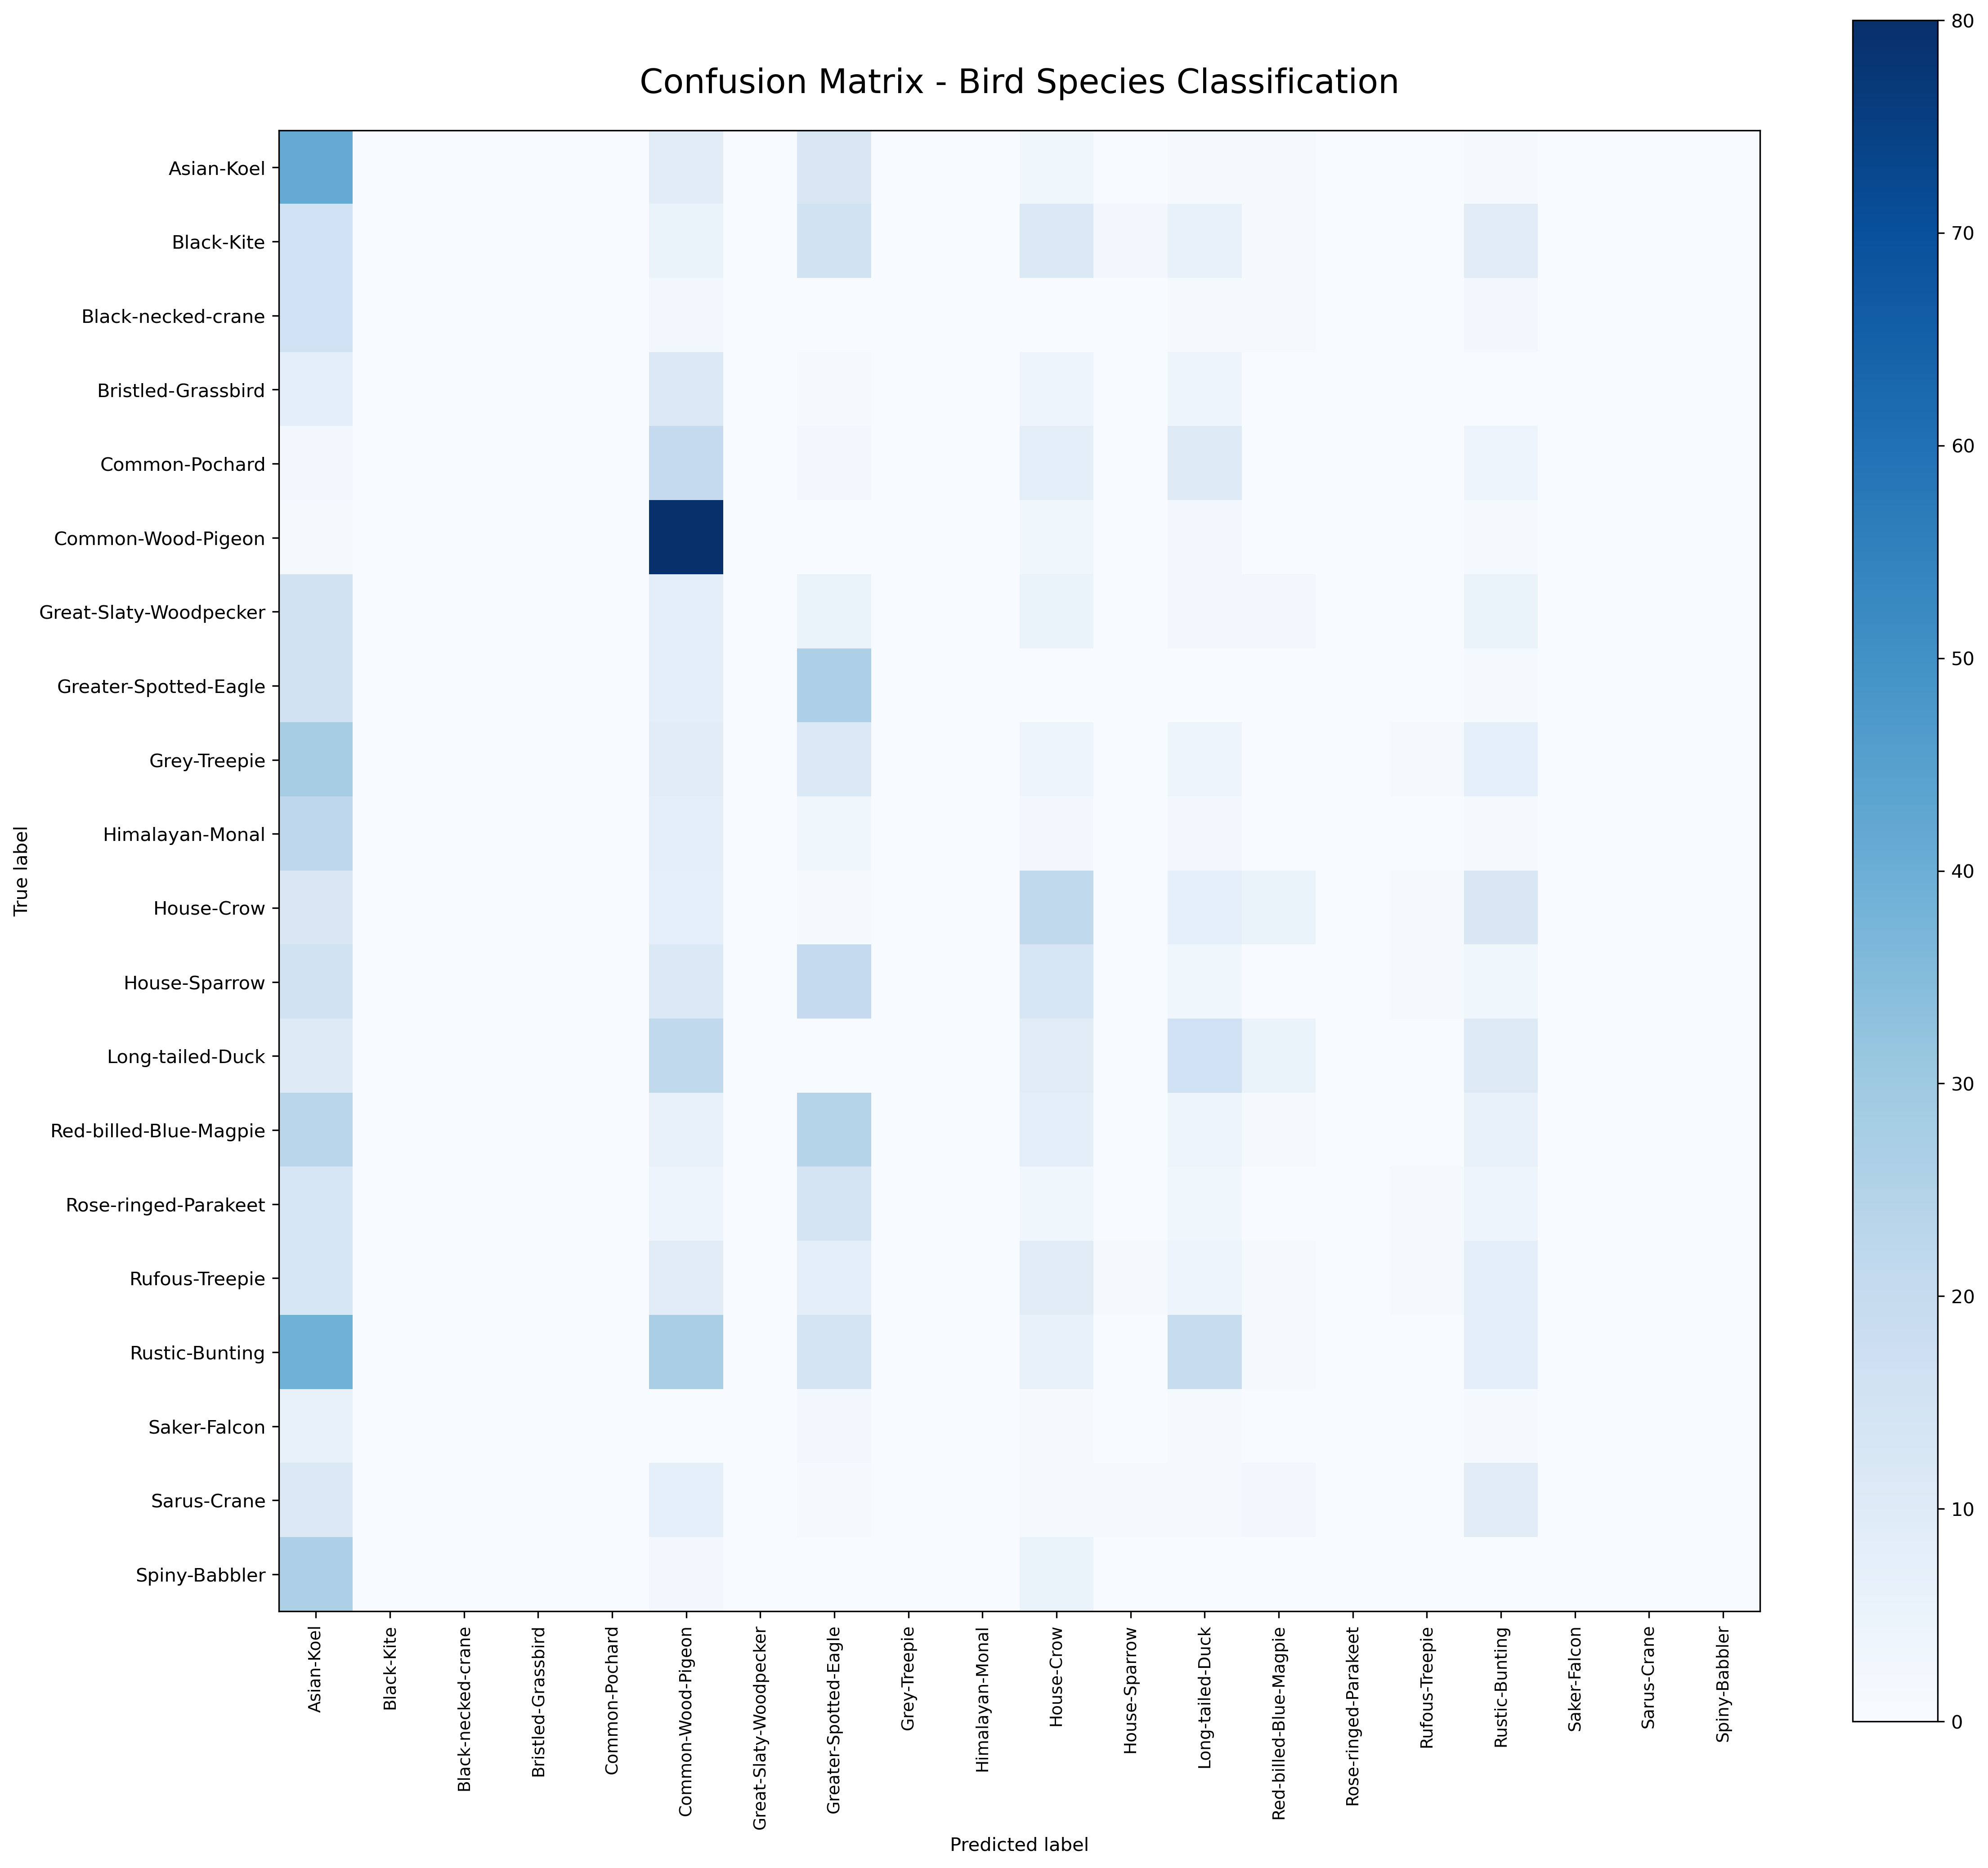

MODEL EVALUATION METRICS

Accuracy Score: 0.1810 (18.10%)
Precision Score: 0.0866
Recall Score: 0.1810
F1 Score: 0.1015

Log Loss: 2.6233

PER-CLASS PERFORMANCE

                        precision    recall  f1-score   support

            Asian-Koel     0.1235    0.6029    0.2050        68
            Black-Kite     0.0000    0.0000    0.0000        65
    Black-necked-crane     0.0000    0.0000    0.0000        22
    Bristled-Grassbird     0.0000    0.0000    0.0000        28
        Common-Pochard     0.0000    0.0000    0.0000        46
    Common-Wood-Pigeon     0.3150    0.9195    0.4692        87
Great-Slaty-Woodpecker     0.0000    0.0000    0.0000        42
 Greater-Spotted-Eagle     0.1635    0.5200    0.2488        50
          Grey-Treepie     0.0000    0.0000    0.0000        64
       Himalayan-Monal     0.0000    0.0000    0.0000        38
            House-Crow     0.1810    0.3182    0.2308        66
         House-Sparrow     0.0000    0.0000    0.0000        66
     

In [5]:
from IPython.display import display, Image
from pathlib import Path

display_path = "output/iteration-6/"
def display_file(path):
    path = Path(path)
    
    if not path.exists():
        print(f"File not found: {path}")
        return
    
    if path.suffix.lower() == '.txt':
        with open(path, 'r', encoding='utf-8') as f:
            content = f.read()
        print(content)
    
    elif path.suffix.lower() == '.png':
        display(Image(filename=str(path)))
    
    else:
        print(f"Unsupported file type: {path.suffix}")

# Example usage:
# display_file("example.txt")
# display_file("image.png")
print("FCNN Confusion Matrix")
display_file((display_path + "FCNN-Confusion-Matrix.png"))
display_file((display_path + "metricsFCNN.txt"))

print("LSTM Confusion Matrix")
display_file((display_path + "confusion_matrix.png"))
display_file((display_path + "metricsLSTM.txt"))

print("GRU Confusion Matrix")
display_file((display_path + "TL-Confusion-Matrix.png"))
display_file((display_path + "TLMetrics.txt"))

print("FCNN Confsuion Matrix")
display_file((display_path + "GRU-confusion-matrix.png"))
display_file((display_path + "metricsGRU.txt"))
